# Dataset Exploration
### Dataset: Sleep-EDF Expanded

---

**Objective:** Exploring the dataset, so I'll have a better vision of what kinda data I'm dealing with before the preprocessing stage.

**Steps:**
1. Import the dataset paths
2. Load PSG
3. PSG information
4. Load hypnogram
5. Annotation information
6. Plot EEG + annotations
7. Stage statistics
8. Inspect unknown annotation

## 1. Import the dataset

In [3]:
from pathlib import Path
import mne
import numpy as np

# Change this to your actual Sleep-EDF dataset location
DATA_DIR = Path(r"../data/raw")

psg_path = DATA_DIR / "sleep-cassette" / "SC4001E0-PSG.edf"

raw = mne.io.read_raw_edf(
    psg_path,
    preload=False,
    verbose=True
)

print(raw)

Extracting EDF parameters from ..\data\raw\sleep-cassette\SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~10 KiB, data not loaded>


C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_129332\1537552277.py:10: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_129332\1537552277.py:10: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_129332\1537552277.py:10: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(


## 2. PSG information

In [4]:
print("\n--- BASIC INFORMATION ---")
print("Number of channels:", len(raw.ch_names))
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Recording duration:", raw.times[-1], "seconds")
print("Recording duration:", raw.times[-1] / 3600, "hours")

print("\n--- CHANNELS ---")
for i, channel in enumerate(raw.ch_names):
    print(i, channel)


--- BASIC INFORMATION ---
Number of channels: 7
Sampling frequency: 100.0 Hz
Recording duration: 79499.99 seconds
Recording duration: 22.083330555555555 hours

--- CHANNELS ---
0 EEG Fpz-Cz
1 EEG Pz-Oz
2 EOG horizontal
3 Resp oro-nasal
4 EMG submental
5 Temp rectal
6 Event marker


## 3. Load hypnogram

In [5]:
hypnogram_path = DATA_DIR / "sleep-cassette" / "SC4001EC-Hypnogram.edf"

annotations = mne.read_annotations(hypnogram_path)

print(annotations)

<Annotations | 154 segments: Sleep stage 1 (24), Sleep stage 2 (40), Sleep ...>


## 4. Annotation information

In [6]:
print("\n--- ANNOTATIONS ---")
print("Number of annotations:", len(annotations))

for onset, duration, description in zip(
    annotations.onset,
    annotations.duration,
    annotations.description
):
    print(
        f"Onset: {onset:8.2f}s | "
        f"Duration: {duration:6.2f}s | "
        f"Stage: {description}"
    )


--- ANNOTATIONS ---
Number of annotations: 154
Onset:     0.00s | Duration: 30630.00s | Stage: Sleep stage W
Onset: 30630.00s | Duration: 120.00s | Stage: Sleep stage 1
Onset: 30750.00s | Duration: 390.00s | Stage: Sleep stage 2
Onset: 31140.00s | Duration:  30.00s | Stage: Sleep stage 3
Onset: 31170.00s | Duration:  30.00s | Stage: Sleep stage 2
Onset: 31200.00s | Duration: 150.00s | Stage: Sleep stage 3
Onset: 31350.00s | Duration:  30.00s | Stage: Sleep stage 4
Onset: 31380.00s | Duration:  60.00s | Stage: Sleep stage 3
Onset: 31440.00s | Duration:  60.00s | Stage: Sleep stage 4
Onset: 31500.00s | Duration:  30.00s | Stage: Sleep stage 3
Onset: 31530.00s | Duration: 120.00s | Stage: Sleep stage 4
Onset: 31650.00s | Duration:  30.00s | Stage: Sleep stage 3
Onset: 31680.00s | Duration: 120.00s | Stage: Sleep stage 4
Onset: 31800.00s | Duration:  30.00s | Stage: Sleep stage W
Onset: 31830.00s | Duration:  60.00s | Stage: Sleep stage 3
Onset: 31890.00s | Duration:  60.00s | Stage: Slee

## 5. Plot EEG + annotations

Using matplotlib as 2D backend.


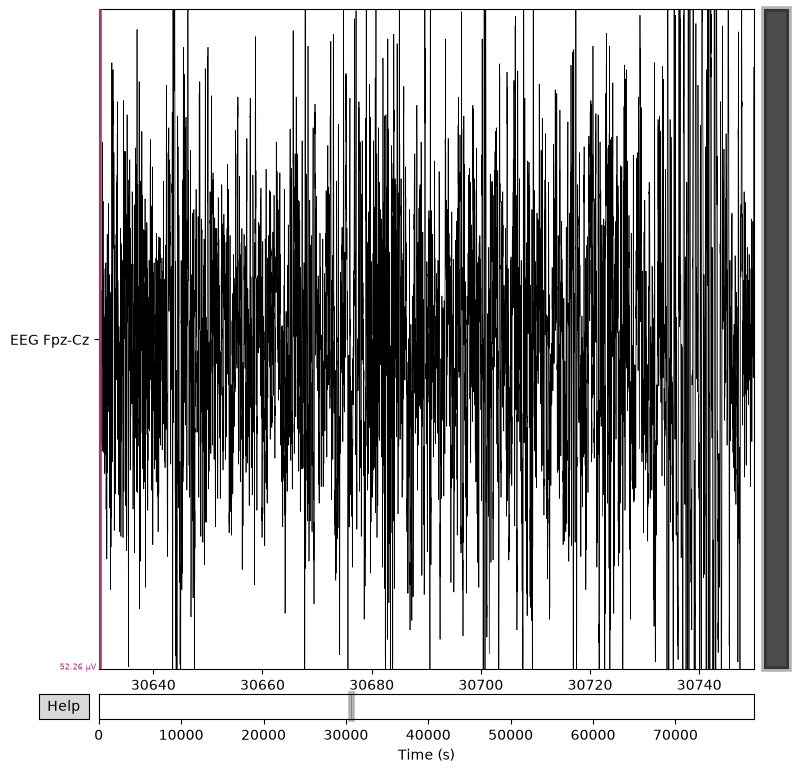

In [7]:
import matplotlib.pyplot as plt

# Select the Fpz-Cz EEG channel
eeg = raw.copy().pick(["EEG Fpz-Cz"])

# Plot 2 minutes beginning at the first scored sleep epoch
start_time = 30630
duration = 120

eeg.plot(
    start=start_time,
    duration=duration,
    scalings="auto",
    title="SC4001 - EEG Fpz-Cz around Sleep Onset"
)

plt.show()

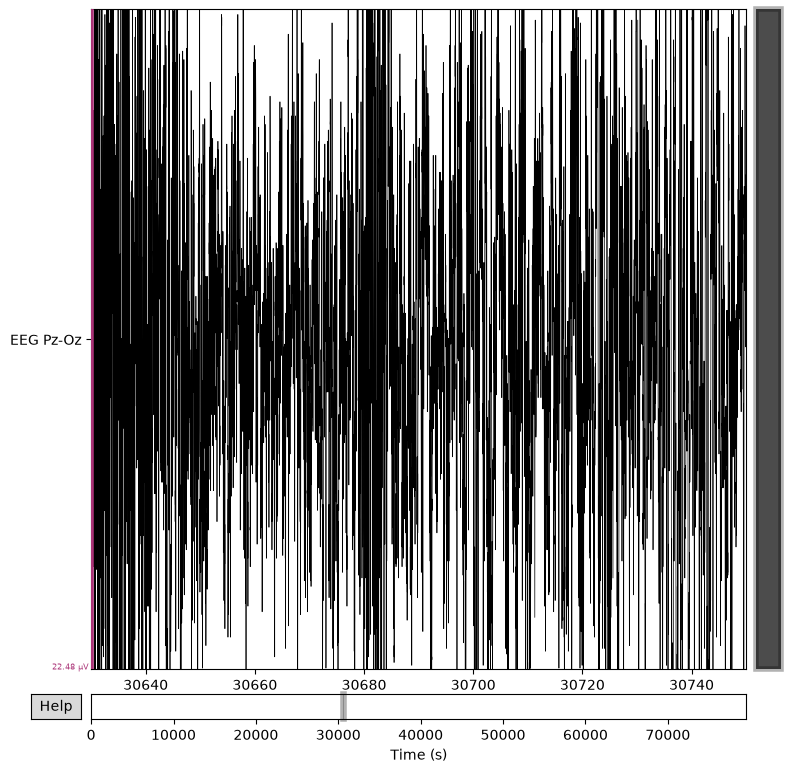

In [8]:
eeg2 = raw.copy().pick(["EEG Pz-Oz"])

eeg2.plot(
    start=30630,
    duration=120,
    scalings="auto",
    title="SC4001 - EEG Pz-Oz around Sleep Onset"
)

plt.show()

C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_129332\1843798298.py:1: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_129332\1843798298.py:3: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(
C:\Users\ELECOMP\AppData\Local\Temp\ipykernel_129332\1843798298.py:3: RuntimeWarning: Loading an EDF with mixed sampling frequencies and preload=False will result in edge artifacts. It is recommended to use preload=True.See also https://github.com/mne-tools/mne-python/issues/10635
  raw.plot(


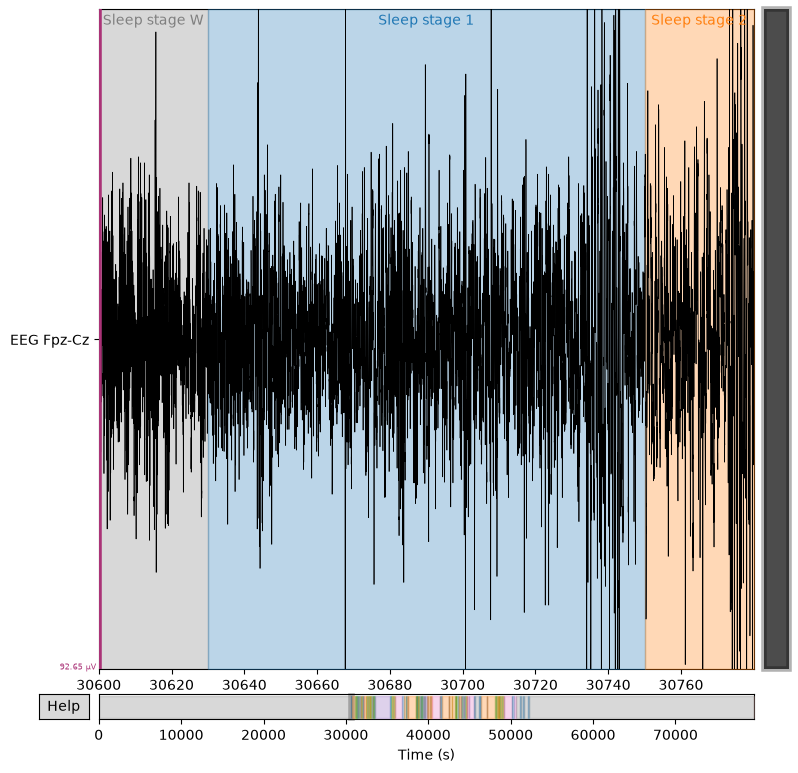

In [9]:
raw.set_annotations(annotations)

raw.plot(
    picks=["EEG Fpz-Cz"],
    start=30600,
    duration=180,
    scalings="auto",
    title="SC4001 - EEG with Sleep-Stage Annotations"
)

plt.show()

## 6. Stage statistics

In [10]:
from collections import Counter

stage_counts = Counter(annotations.description)

for stage, count in stage_counts.items():
    print(f"{stage}: {count}")

Sleep stage W: 12
Sleep stage 1: 24
Sleep stage 2: 40
Sleep stage 3: 48
Sleep stage 4: 23
Sleep stage R: 6
Sleep stage ?: 1


## 7. Inspect unknown annotation

In [11]:
for onset, duration, description in zip(
    annotations.onset,
    annotations.duration,
    annotations.description
):
    if description == "Sleep stage ?":
        print(f"Unknown stage found:")
        print(f"  Onset:    {onset} seconds")
        print(f"  Duration: {duration} seconds")

Unknown stage found:
  Onset:    79500.0 seconds
  Duration: 6900.0 seconds


## 8. Calculate the number of 30-second epochs per stage

In [12]:
from collections import defaultdict

epoch_counts = defaultdict(int)

for duration, description in zip(
    annotations.duration,
    annotations.description
):
    # Number of complete 30-second epochs in this annotation
    n_epochs = int(duration // 30)

    epoch_counts[description] += n_epochs

print("Number of complete 30-second epochs:")
print("-" * 40)

for stage, count in epoch_counts.items():
    print(f"{stage}: {count}")

print("-" * 40)
print("Total:", sum(epoch_counts.values()))

Number of complete 30-second epochs:
----------------------------------------
Sleep stage W: 1997
Sleep stage 1: 58
Sleep stage 2: 250
Sleep stage 3: 101
Sleep stage 4: 119
Sleep stage R: 125
Sleep stage ?: 230
----------------------------------------
Total: 2880


## 9. Check annotation durations

In [13]:
print("Annotations whose duration is not an exact multiple of 30 seconds:")
print("-" * 60)

found = False

for onset, duration, description in zip(
    annotations.onset,
    annotations.duration,
    annotations.description
):
    if duration % 30 != 0:
        found = True
        print(
            f"Onset: {onset:.2f}s | "
            f"Duration: {duration:.2f}s | "
            f"Stage: {description}"
        )

if not found:
    print("All annotation durations are exact multiples of 30 seconds.")

Annotations whose duration is not an exact multiple of 30 seconds:
------------------------------------------------------------
All annotation durations are exact multiples of 30 seconds.


## 10. Build 30-second epoch table

In [14]:
import pandas as pd

EPOCH_DURATION = 30.0
SUBJECT_ID = "SC4001"

stage_mapping = {
    "Sleep stage W": "W",
    "Sleep stage 1": "N1",
    "Sleep stage 2": "N2",
    "Sleep stage 3": "N3",
    "Sleep stage 4": "N3",
    "Sleep stage R": "REM",
}

epoch_records = []
epoch_index = 0

for onset, duration, description in zip(
    annotations.onset,
    annotations.duration,
    annotations.description
):
    # Ignore annotations that do not have an EEG target
    if description not in stage_mapping:
        continue

    target_stage = stage_mapping[description]

    # Number of 30-second epochs in this annotation
    n_epochs = int(duration / EPOCH_DURATION)

    for i in range(n_epochs):
        start_time = onset + i * EPOCH_DURATION
        end_time = start_time + EPOCH_DURATION

        epoch_records.append({
            "subject_id": SUBJECT_ID,
            "epoch_index": epoch_index,
            "start_time": start_time,
            "end_time": end_time,
            "raw_stage": description,
            "target_stage": target_stage,
        })

        epoch_index += 1

epochs_df = pd.DataFrame(epoch_records)

print("Number of epochs:", len(epochs_df))
print("\nFirst 10 epochs:")
print(epochs_df.head(10))

print("\nLast 10 epochs:")
print(epochs_df.tail(10))

Number of epochs: 2650

First 10 epochs:
  subject_id  epoch_index  start_time  end_time      raw_stage target_stage
0     SC4001            0         0.0      30.0  Sleep stage W            W
1     SC4001            1        30.0      60.0  Sleep stage W            W
2     SC4001            2        60.0      90.0  Sleep stage W            W
3     SC4001            3        90.0     120.0  Sleep stage W            W
4     SC4001            4       120.0     150.0  Sleep stage W            W
5     SC4001            5       150.0     180.0  Sleep stage W            W
6     SC4001            6       180.0     210.0  Sleep stage W            W
7     SC4001            7       210.0     240.0  Sleep stage W            W
8     SC4001            8       240.0     270.0  Sleep stage W            W
9     SC4001            9       270.0     300.0  Sleep stage W            W

Last 10 epochs:
     subject_id  epoch_index  start_time  end_time      raw_stage target_stage
2640     SC4001         264

## 11. Validate epoch table

In [15]:
print("Total epochs:", len(epochs_df))

print("\nTarget-stage distribution:")
print(epochs_df["target_stage"].value_counts())

print("\nRaw-stage distribution:")
print(epochs_df["raw_stage"].value_counts())

# Calculate the actual recording duration from the number of samples
# rather than using raw.times[-1], which is the timestamp of the last sample.
actual_duration = raw.n_times / raw.info["sfreq"]

print("\nActual PSG duration:")
print(actual_duration, "seconds")

print("\nExpected number of 30-second epochs:")
expected_epochs = int(actual_duration / EPOCH_DURATION)
print(expected_epochs)

print("\nDoes the epoch count match the PSG duration?")
print(len(epochs_df) == expected_epochs)

Total epochs: 2650

Target-stage distribution:
target_stage
W      1997
N2      250
N3      220
REM     125
N1       58
Name: count, dtype: int64

Raw-stage distribution:
raw_stage
Sleep stage W    1997
Sleep stage 2     250
Sleep stage R     125
Sleep stage 4     119
Sleep stage 3     101
Sleep stage 1      58
Name: count, dtype: int64

Actual PSG duration:
79500.0 seconds

Expected number of 30-second epochs:
2650

Does the epoch count match the PSG duration?
True


## 12. Check epoch continuity

In [16]:
expected_start_times = (
    epochs_df["epoch_index"] * EPOCH_DURATION
)

actual_start_times = epochs_df["start_time"]

continuity_ok = (
    expected_start_times.round(6)
    == actual_start_times.round(6)
).all()

print("Are all epoch start times continuous from t=0?")
print(continuity_ok)

print("\nFirst epoch:")
print(epochs_df.iloc[0])

print("\nFirst sleep epoch:")
print(
    epochs_df[
        epochs_df["start_time"] == 30630.0
    ]
)

print("\nLast epoch:")
print(epochs_df.iloc[-1])

Are all epoch start times continuous from t=0?
True

First epoch:
subject_id             SC4001
epoch_index                 0
start_time                0.0
end_time                 30.0
raw_stage       Sleep stage W
target_stage                W
Name: 0, dtype: object

First sleep epoch:
     subject_id  epoch_index  start_time  end_time      raw_stage target_stage
1021     SC4001         1021     30630.0   30660.0  Sleep stage 1           N1

Last epoch:
subject_id             SC4001
epoch_index              2649
start_time            79470.0
end_time              79500.0
raw_stage       Sleep stage W
target_stage                W
Name: 2649, dtype: object


## 13. Load and extract Fpz-Cz EEG

In [17]:
EEG_CHANNEL = "EEG Fpz-Cz"

# Load only the EEG channel we need
eeg_raw = mne.io.read_raw_edf(
    psg_path,
    include=[EEG_CHANNEL],
    preload=True,
    verbose=False
)

print("Channel:", eeg_raw.ch_names)
print("Sampling frequency:", eeg_raw.info["sfreq"], "Hz")
print("Number of samples:", eeg_raw.n_times)
print(
    "Duration:",
    eeg_raw.n_times / eeg_raw.info["sfreq"],
    "seconds"
)

Channel: ['EEG Fpz-Cz']
Sampling frequency: 100.0 Hz
Number of samples: 7950000
Duration: 79500.0 seconds


## 14. Verify samples per epoch

In [18]:
SFREQ = eeg_raw.info["sfreq"]
EPOCH_SAMPLES = int(EPOCH_DURATION * SFREQ)

print("Sampling frequency:", SFREQ)
print("Epoch duration:", EPOCH_DURATION, "seconds")
print("Expected samples per epoch:", EPOCH_SAMPLES)

# Extract the first 30-second epoch
first_epoch = eeg_raw.get_data(
    start=0,
    stop=EPOCH_SAMPLES
)[0]

print("\nFirst epoch shape:", first_epoch.shape)
print("Number of samples:", len(first_epoch))

Sampling frequency: 100.0
Epoch duration: 30.0 seconds
Expected samples per epoch: 3000

First epoch shape: (3000,)
Number of samples: 3000


## 15. Verify the first N1 EEG epoch

In [19]:
n1_epoch_index = 1021

row = epochs_df.iloc[n1_epoch_index]

start_sample = int(row["start_time"] * SFREQ)
end_sample = int(row["end_time"] * SFREQ)

n1_epoch = eeg_raw.get_data(
    start=start_sample,
    stop=end_sample
)[0]

print("Epoch index:", row["epoch_index"])
print("Start time:", row["start_time"])
print("End time:", row["end_time"])
print("Raw stage:", row["raw_stage"])
print("Target stage:", row["target_stage"])
print("Number of EEG samples:", len(n1_epoch))

Epoch index: 1021
Start time: 30630.0
End time: 30660.0
Raw stage: Sleep stage 1
Target stage: N1
Number of EEG samples: 3000


## 16. Function to extract 30-second EEG epochs

In [20]:
def extract_eeg_epochs(eeg_raw, epochs_df):
    """
    Extract EEG samples for every epoch in epochs_df.

    Parameters
    ----------
    eeg_raw : mne.io.Raw
        Preloaded raw EEG recording.
    epochs_df : pandas.DataFrame
        DataFrame containing start_time and end_time for each epoch.

    Returns
    -------
    X : numpy.ndarray
        EEG epochs with shape:
        (number_of_epochs, samples_per_epoch)
    """
    
    sfreq = eeg_raw.info["sfreq"]
    epoch_samples = int(EPOCH_DURATION * sfreq)

    X = []

    for _, row in epochs_df.iterrows():
        start_sample = int(round(row["start_time"] * sfreq))
        end_sample = start_sample + epoch_samples

        epoch = eeg_raw.get_data(
            start=start_sample,
            stop=end_sample
        )[0]

        # Validate epoch length
        if len(epoch) != epoch_samples:
            raise ValueError(
                f"Unexpected epoch length for epoch "
                f"{row['epoch_index']}: "
                f"expected {epoch_samples}, got {len(epoch)}"
            )

        X.append(epoch)

    return np.asarray(X)

## 17. Extract all EEG epochs for SC4001

In [21]:
X = extract_eeg_epochs(
    eeg_raw=eeg_raw,
    epochs_df=epochs_df
)

print("EEG epoch array shape:", X.shape)
print("Data type:", X.dtype)
print("Minimum value:", X.min())
print("Maximum value:", X.max())

EEG epoch array shape: (2650, 3000)
Data type: float64
Minimum value: -0.000192
Maximum value: 0.0001706197802197802


## 18. Verify EEG epoch / label correspondence

In [22]:
test_indices = [0, 1021, 1500, 2000, 2649]

for idx in test_indices:
    row = epochs_df.iloc[idx]

    print(
        f"Epoch {idx:4d} | "
        f"{row['start_time']:8.1f}s - {row['end_time']:8.1f}s | "
        f"{row['target_stage']:>3} | "
        f"Samples: {len(X[idx])}"
    )

Epoch    0 |      0.0s -     30.0s |   W | Samples: 3000
Epoch 1021 |  30630.0s -  30660.0s |  N1 | Samples: 3000
Epoch 1500 |  45000.0s -  45030.0s | REM | Samples: 3000
Epoch 2000 |  60000.0s -  60030.0s |   W | Samples: 3000
Epoch 2649 |  79470.0s -  79500.0s |   W | Samples: 3000


## 19. Save extracted SC4001 epochs

In [23]:
from pathlib import Path

PROCESSED_DIR = DATA_DIR.parent / "processed"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

np.save(
    PROCESSED_DIR / "SC4001_Fpz-Cz_epochs.npy",
    X
)

epochs_df.to_csv(
    PROCESSED_DIR / "SC4001_epochs_metadata.csv",
    index=False
)

print("Saved:")
print(PROCESSED_DIR / "SC4001_Fpz-Cz_epochs.npy")
print(PROCESSED_DIR / "SC4001_epochs_metadata.csv")

Saved:
..\data\processed\SC4001_Fpz-Cz_epochs.npy
..\data\processed\SC4001_epochs_metadata.csv


## 20. Inspect raw EEG frequency spectrum

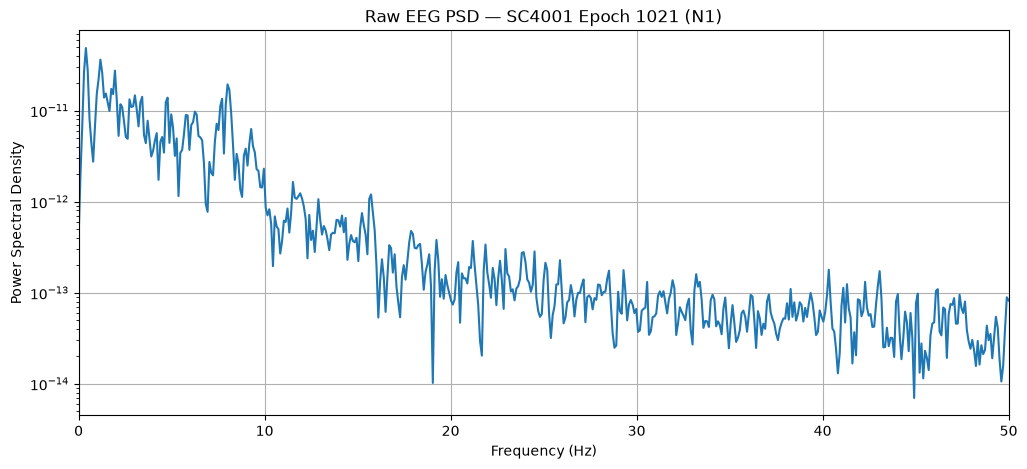

In [24]:
from scipy.signal import welch

# Use the first N1 epoch as a representative example
example_epoch_index = 1021
example_epoch = X[example_epoch_index]

# Sampling frequency
fs = SFREQ

# Estimate Power Spectral Density using Welch's method
frequencies, psd = welch(
    example_epoch,
    fs=fs,
    nperseg=1024
)

# Plot the PSD
plt.figure(figsize=(12, 5))

plt.semilogy(frequencies, psd)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(
    f"Raw EEG PSD — SC4001 Epoch {example_epoch_index} "
    f"({epochs_df.iloc[example_epoch_index]['target_stage']})"
)

plt.xlim(0, 50)
plt.grid(True)

plt.show()

## 21. Compare Wake and REM spectra

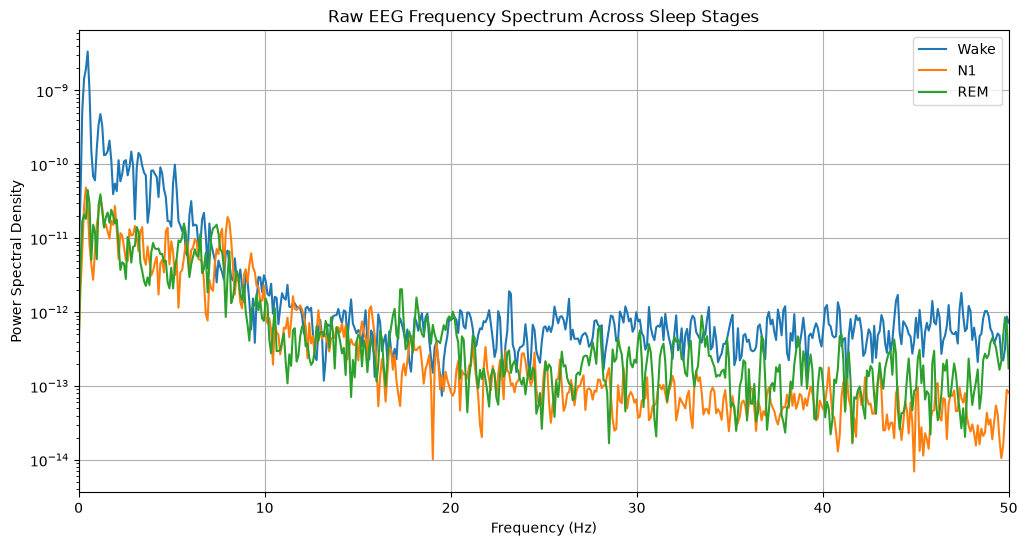

In [25]:
stage_examples = {
    "Wake": 0,
    "N1": 1021,
    "REM": 1500,
}

plt.figure(figsize=(12, 6))

for stage_name, epoch_index in stage_examples.items():
    epoch = X[epoch_index]

    frequencies, psd = welch(
        epoch,
        fs=SFREQ,
        nperseg=1024
    )

    plt.semilogy(
        frequencies,
        psd,
        label=stage_name
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Raw EEG Frequency Spectrum Across Sleep Stages")

plt.xlim(0, 50)
plt.legend()
plt.grid(True)

plt.show()

## 22. Create the filtered continuous EEG

In [26]:
FILTER_LOW = 0.3
FILTER_HIGH = 35.0

filtered_eeg_raw = eeg_raw.copy()

filtered_eeg_raw.filter(
    l_freq=FILTER_LOW,
    h_freq=FILTER_HIGH,
    method="fir",
    phase="zero",
    verbose=True
)

print("Filtering completed.")
print("High-pass:", FILTER_LOW, "Hz")
print("Low-pass:", FILTER_HIGH, "Hz")
print("Sampling frequency:", filtered_eeg_raw.info["sfreq"], "Hz")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.30
- Lower transition bandwidth: 0.30 Hz (-6 dB cutoff frequency: 0.15 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 1101 samples (11.010 s)

Filtering completed.
High-pass: 0.3 Hz
Low-pass: 35.0 Hz
Sampling frequency: 100.0 Hz


## 23. Compare raw and filtered EEG

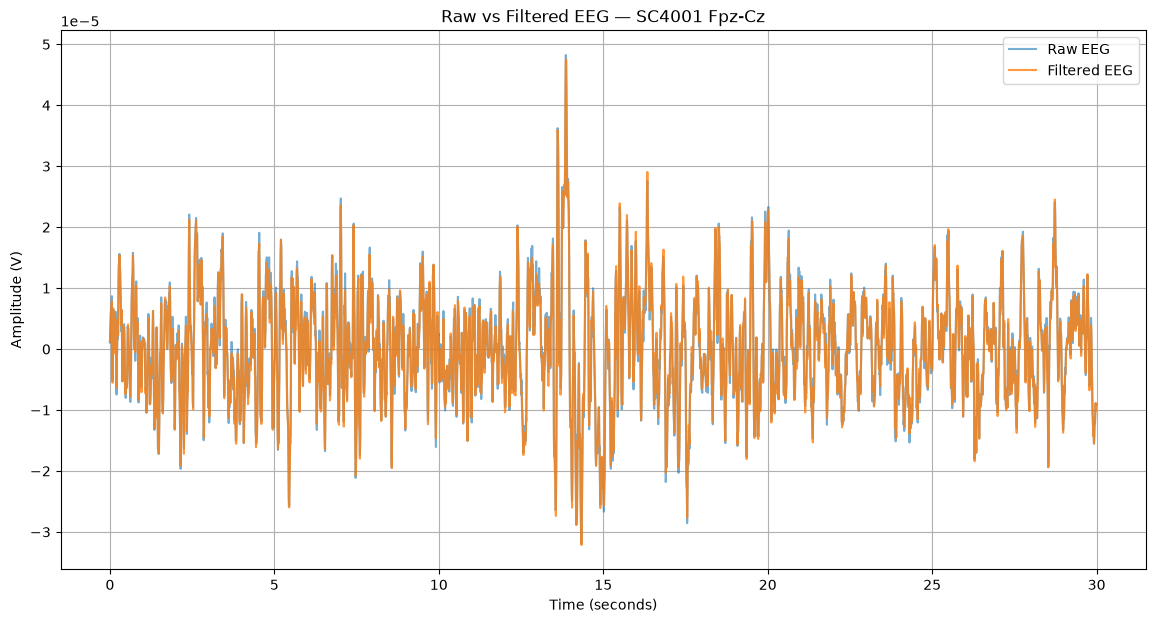

In [27]:
comparison_start = 30630
comparison_duration = 30

raw_data = eeg_raw.get_data(
    start=int(comparison_start * SFREQ),
    stop=int((comparison_start + comparison_duration) * SFREQ)
)[0]

filtered_data = filtered_eeg_raw.get_data(
    start=int(comparison_start * SFREQ),
    stop=int((comparison_start + comparison_duration) * SFREQ)
)[0]

time = np.arange(len(raw_data)) / SFREQ

plt.figure(figsize=(14, 7))

plt.plot(
    time,
    raw_data,
    label="Raw EEG",
    alpha=0.6
)

plt.plot(
    time,
    filtered_data,
    label="Filtered EEG",
    alpha=0.8
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.title("Raw vs Filtered EEG — SC4001 Fpz-Cz")
plt.legend()
plt.grid(True)

plt.show()

## 24. Compare raw and filtered PSD

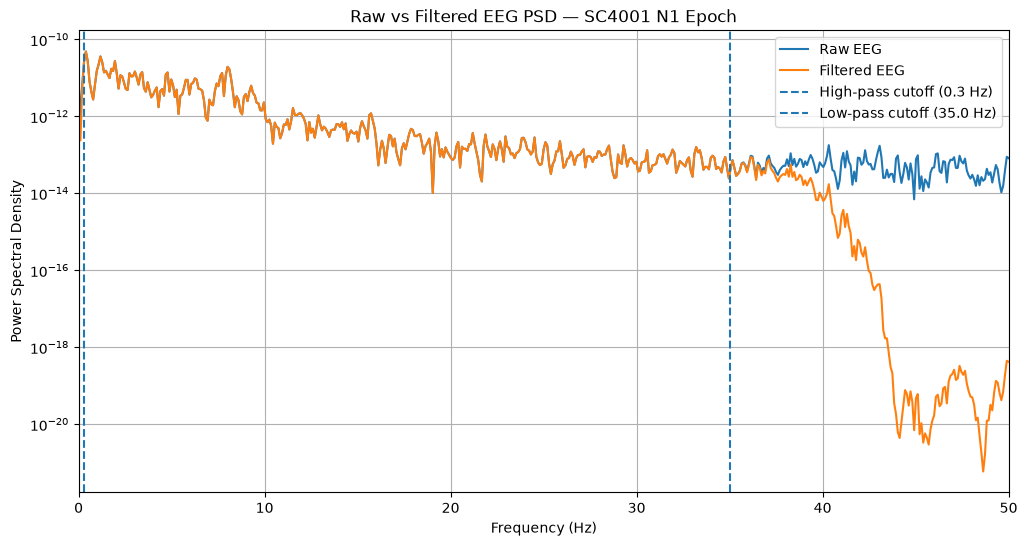

In [28]:
raw_frequencies, raw_psd = welch(
    raw_data,
    fs=SFREQ,
    nperseg=1024
)

filtered_frequencies, filtered_psd = welch(
    filtered_data,
    fs=SFREQ,
    nperseg=1024
)

plt.figure(figsize=(12, 6))

plt.semilogy(
    raw_frequencies,
    raw_psd,
    label="Raw EEG"
)

plt.semilogy(
    filtered_frequencies,
    filtered_psd,
    label="Filtered EEG"
)

plt.axvline(
    FILTER_LOW,
    linestyle="--",
    label=f"High-pass cutoff ({FILTER_LOW} Hz)"
)

plt.axvline(
    FILTER_HIGH,
    linestyle="--",
    label=f"Low-pass cutoff ({FILTER_HIGH} Hz)"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title("Raw vs Filtered EEG PSD — SC4001 N1 Epoch")

plt.xlim(0, 50)
plt.legend()
plt.grid(True)

plt.show()

## 25. Extract 30-second epochs from the filtered EEG

In [29]:
X_filtered = extract_eeg_epochs(
    eeg_raw=filtered_eeg_raw,
    epochs_df=epochs_df
)

print("Filtered EEG epoch array shape:", X_filtered.shape)
print("Data type:", X_filtered.dtype)
print("Minimum value:", X_filtered.min())
print("Maximum value:", X_filtered.max())

Filtered EEG epoch array shape: (2650, 3000)
Data type: float64
Minimum value: -0.00019206995673705122
Maximum value: 0.0001694162670597789


## 26. Compare raw and filtered N1 epoch

In [30]:
example_index = 1021

print("Epoch:", example_index)
print("Start:", epochs_df.iloc[example_index]["start_time"])
print("End:", epochs_df.iloc[example_index]["end_time"])
print("Stage:", epochs_df.iloc[example_index]["target_stage"])

print("\nRaw epoch shape:", X[example_index].shape)
print("Filtered epoch shape:", X_filtered[example_index].shape)

Epoch: 1021
Start: 30630.0
End: 30660.0
Stage: N1

Raw epoch shape: (3000,)
Filtered epoch shape: (3000,)


## 27. Plot raw vs filtered EEG

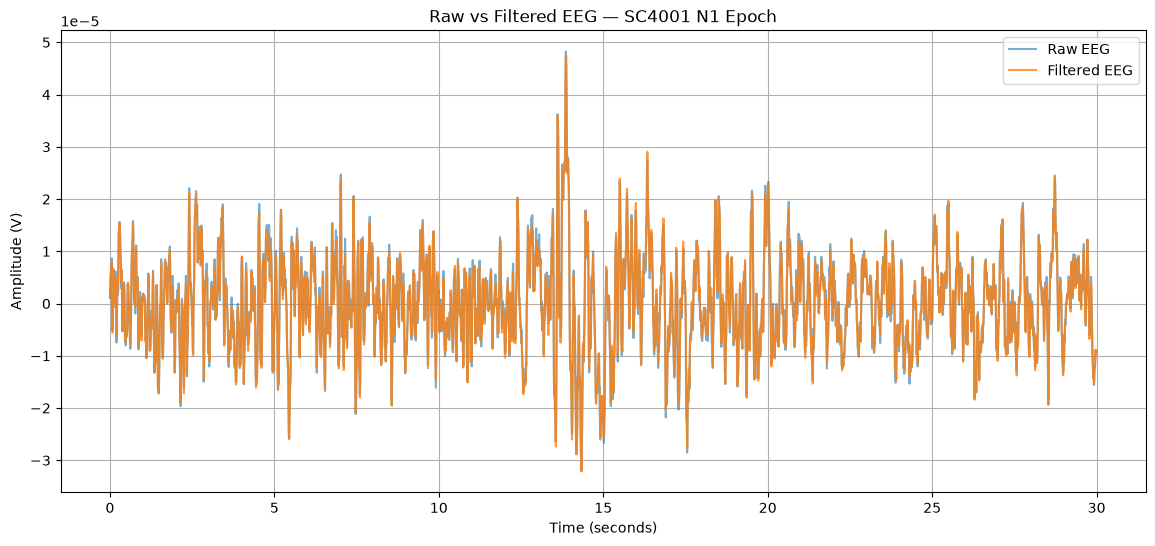

In [31]:
example_index = 1021

time = np.arange(EPOCH_SAMPLES) / SFREQ

plt.figure(figsize=(14, 6))

plt.plot(
    time,
    X[example_index],
    label="Raw EEG",
    alpha=0.6
)

plt.plot(
    time,
    X_filtered[example_index],
    label="Filtered EEG",
    alpha=0.8
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.title("Raw vs Filtered EEG — SC4001 N1 Epoch")

plt.legend()
plt.grid(True)

plt.show()

## 28. Save filtered EEG epochs

In [32]:
filtered_epochs_path = (
    PROCESSED_DIR / "SC4001_Fpz-Cz_filtered_epochs.npy"
)

np.save(
    filtered_epochs_path,
    X_filtered
)

print("Saved filtered epochs to:")
print(filtered_epochs_path)

Saved filtered epochs to:
..\data\processed\SC4001_Fpz-Cz_filtered_epochs.npy


## 29. Define EEG frequency bands

In [33]:
FREQUENCY_BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
}

print("Frequency bands:")

for band, (low, high) in FREQUENCY_BANDS.items():
    print(f"{band:>6}: {low:>4.1f}–{high:>4.1f} Hz")

Frequency bands:
 delta:  0.5– 4.0 Hz
 theta:  4.0– 8.0 Hz
 alpha:  8.0–13.0 Hz
  beta: 13.0–30.0 Hz


## 30. Calculate band power for one epoch

In [34]:
from scipy.integrate import trapezoid

example_index = 1021
example_epoch = X_filtered[example_index]

frequencies, psd = welch(
    example_epoch,
    fs=SFREQ,
    nperseg=1024
)

band_powers = {}

for band, (low, high) in FREQUENCY_BANDS.items():
    mask = (frequencies >= low) & (frequencies < high)

    power = trapezoid(
        psd[mask],
        frequencies[mask]
    )

    band_powers[band] = power

print(
    f"SC4001 Epoch {example_index} "
    f"({epochs_df.iloc[example_index]['target_stage']})"
)

for band, power in band_powers.items():
    print(f"{band:>6} power: {power:.6e}")

SC4001 Epoch 1021 (N1)
 delta power: 3.946261e-11
 theta power: 2.219669e-11
 alpha power: 1.064721e-11
  beta power: 3.478408e-12


## 31. Visualize absolute band power

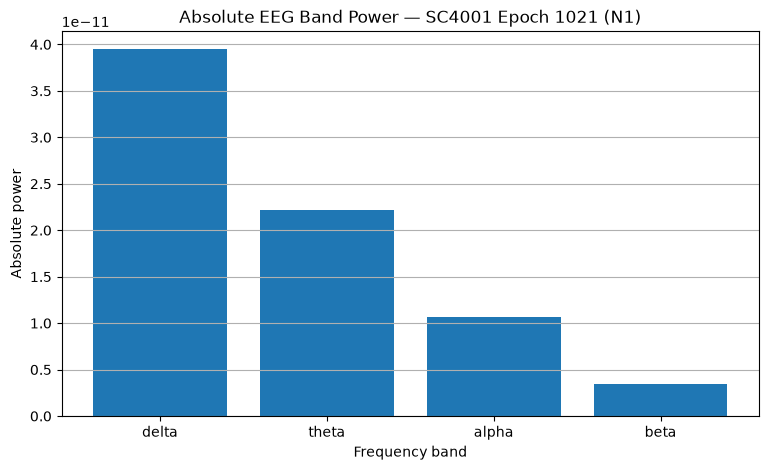

In [35]:
plt.figure(figsize=(9, 5))

plt.bar(
    list(band_powers.keys()),
    list(band_powers.values())
)

plt.xlabel("Frequency band")
plt.ylabel("Absolute power")
plt.title(
    f"Absolute EEG Band Power — "
    f"SC4001 Epoch {example_index} "
    f"({epochs_df.iloc[example_index]['target_stage']})"
)

plt.grid(axis="y")
plt.show()

## 32. Define frequency feature extraction function

In [36]:
def extract_frequency_features(
    epoch,
    sfreq,
    frequency_bands,
    nperseg=1024
):
    """
    Extract absolute and relative frequency-band power
    from one EEG epoch.

    Parameters
    ----------
    epoch : numpy.ndarray
        One EEG epoch.
    sfreq : float
        EEG sampling frequency.
    frequency_bands : dict
        Dictionary containing band names and (low, high) limits.
    nperseg : int
        Segment length used by Welch's PSD estimation.

    Returns
    -------
    features : dict
        Absolute and relative band-power features.
    """

    frequencies, psd = welch(
        epoch,
        fs=sfreq,
        nperseg=nperseg
    )

    absolute_power = {}

    for band, (low, high) in frequency_bands.items():

        mask = (
            (frequencies >= low)
            & (frequencies < high)
        )

        power = trapezoid(
            psd[mask],
            frequencies[mask]
        )

        absolute_power[band] = power

    # Total spectral power in the 0.5–30 Hz range
    total_power = sum(absolute_power.values())

    features = {}

    for band, power in absolute_power.items():

        features[f"{band}_absolute"] = power

        if total_power > 0:
            features[f"{band}_relative"] = power / total_power
        else:
            features[f"{band}_relative"] = 0.0

    return features

## 33. Test frequency feature extraction

In [37]:
example_index = 1021

example_features = extract_frequency_features(
    epoch=X_filtered[example_index],
    sfreq=SFREQ,
    frequency_bands=FREQUENCY_BANDS
)

print(
    f"SC4001 Epoch {example_index} "
    f"({epochs_df.iloc[example_index]['target_stage']})"
)

for feature_name, value in example_features.items():
    print(f"{feature_name:>20}: {value:.6e}")

SC4001 Epoch 1021 (N1)
      delta_absolute: 3.946261e-11
      delta_relative: 5.207185e-01
      theta_absolute: 2.219669e-11
      theta_relative: 2.928906e-01
      alpha_absolute: 1.064721e-11
      alpha_relative: 1.404925e-01
       beta_absolute: 3.478408e-12
       beta_relative: 4.589842e-02


## 34. Verify relative band powers

In [38]:
relative_power_sum = sum(
    value
    for name, value in example_features.items()
    if name.endswith("_relative")
)

print("Sum of relative band powers:")
print(relative_power_sum)

print("\nRelative band powers:")
for name, value in example_features.items():
    if name.endswith("_relative"):
        print(f"{name:>20}: {value:.6f}")

Sum of relative band powers:
1.0000000000000002

Relative band powers:
      delta_relative: 0.520719
      theta_relative: 0.292891
      alpha_relative: 0.140492
       beta_relative: 0.045898


## 35. Extract frequency features from all SC4001 epochs

In [39]:
feature_records = []

for epoch_index, epoch in enumerate(X_filtered):

    features = extract_frequency_features(
        epoch=epoch,
        sfreq=SFREQ,
        frequency_bands=FREQUENCY_BANDS
    )

    features["epoch_index"] = epoch_index

    feature_records.append(features)

features_df = pd.DataFrame(feature_records)

# Put epoch_index first
feature_columns = [
    "epoch_index",
    "delta_absolute",
    "delta_relative",
    "theta_absolute",
    "theta_relative",
    "alpha_absolute",
    "alpha_relative",
    "beta_absolute",
    "beta_relative",
]

features_df = features_df[feature_columns]

print("Feature DataFrame shape:", features_df.shape)
print("\nFirst 5 rows:")
print(features_df.head())

Feature DataFrame shape: (2650, 9)

First 5 rows:
   epoch_index  delta_absolute  delta_relative  theta_absolute  \
0            0    4.440571e-10        0.790025    9.889418e-11   
1            1    2.597151e-10        0.754247    4.180098e-11   
2            2    3.779352e-10        0.874724    2.401454e-11   
3            3    2.028651e-10        0.837688    1.827274e-11   
4            4    1.260171e-10        0.673446    4.473053e-11   

   theta_relative  alpha_absolute  alpha_relative  beta_absolute  \
0        0.175943    8.991909e-12        0.015998   1.013694e-11   
1        0.121396    1.341957e-11        0.038972   2.940132e-11   
2        0.055581    1.257038e-11        0.029094   1.754188e-11   
3        0.075453    1.337502e-11        0.055229   7.659840e-12   
4        0.239044    9.939413e-12        0.053117   6.435664e-12   

   beta_relative  
0       0.018035  
1       0.085385  
2       0.040600  
3       0.031630  
4       0.034393  


## 36. Combine frequency features with labels and metadata

In [40]:
model_df = epochs_df.merge(
    features_df,
    on="epoch_index",
    how="inner"
)

print("Model DataFrame shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
print(model_df.head())

Model DataFrame shape: (2650, 14)

Columns:
['subject_id', 'epoch_index', 'start_time', 'end_time', 'raw_stage', 'target_stage', 'delta_absolute', 'delta_relative', 'theta_absolute', 'theta_relative', 'alpha_absolute', 'alpha_relative', 'beta_absolute', 'beta_relative']

First 5 rows:
  subject_id  epoch_index  start_time  end_time      raw_stage target_stage  \
0     SC4001            0         0.0      30.0  Sleep stage W            W   
1     SC4001            1        30.0      60.0  Sleep stage W            W   
2     SC4001            2        60.0      90.0  Sleep stage W            W   
3     SC4001            3        90.0     120.0  Sleep stage W            W   
4     SC4001            4       120.0     150.0  Sleep stage W            W   

   delta_absolute  delta_relative  theta_absolute  theta_relative  \
0    4.440571e-10        0.790025    9.889418e-11        0.175943   
1    2.597151e-10        0.754247    4.180098e-11        0.121396   
2    3.779352e-10        0.87472

## 37. Validate extracted features

In [41]:
feature_only_columns = [
    "delta_absolute",
    "delta_relative",
    "theta_absolute",
    "theta_relative",
    "alpha_absolute",
    "alpha_relative",
    "beta_absolute",
    "beta_relative",
]

print("NaN values:")
print(model_df[feature_only_columns].isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        model_df[feature_only_columns].to_numpy()
    ).sum()
)

print("\nFeature summary:")
print(model_df[feature_only_columns].describe())

NaN values:
delta_absolute    0
delta_relative    0
theta_absolute    0
theta_relative    0
alpha_absolute    0
alpha_relative    0
beta_absolute     0
beta_relative     0
dtype: int64

Infinite values:
0

Feature summary:
       delta_absolute  delta_relative  theta_absolute  theta_relative  \
count    2.650000e+03     2650.000000    2.650000e+03     2650.000000   
mean     3.293546e-10        0.814525    3.602914e-11        0.115700   
std      2.333669e-10        0.096417    1.719727e-11        0.064746   
min      1.409691e-11        0.215285    6.628309e-12        0.020383   
25%      1.821855e-10        0.788594    2.375680e-11        0.080064   
50%      2.919574e-10        0.834995    3.412956e-11        0.099995   
75%      4.183288e-10        0.866972    4.517856e-11        0.130772   
max      1.829576e-09        0.969908    1.802260e-10        0.666883   

       alpha_absolute  alpha_relative  beta_absolute  beta_relative  
count    2.650000e+03     2650.000000   2.650000e

## 38. Compare mean frequency features across sleep stages

In [42]:
stage_feature_means = (
    model_df
    .groupby("target_stage")[feature_only_columns]
    .mean()
)

print(stage_feature_means)

              delta_absolute  delta_relative  theta_absolute  theta_relative  \
target_stage                                                                   
N1              6.617959e-11        0.624413    2.068436e-11        0.235723   
N2              1.840811e-10        0.819867    2.535147e-11        0.122027   
N3              7.761067e-10        0.924061    4.041005e-11        0.057598   
REM             4.263946e-11        0.632247    1.757166e-11        0.254218   
W               3.239146e-10        0.818720    3.848422e-11        0.109153   

              alpha_absolute  alpha_relative  beta_absolute  beta_relative  
target_stage                                                                
N1              5.995083e-12        0.084970   4.623782e-12       0.054894  
N2              7.358228e-12        0.037308   3.892457e-12       0.020798  
N3              9.981718e-12        0.013735   3.044521e-12       0.004605  
REM             4.564329e-12        0.073128   2.46835

## 39. Visualize relative band power by sleep stage

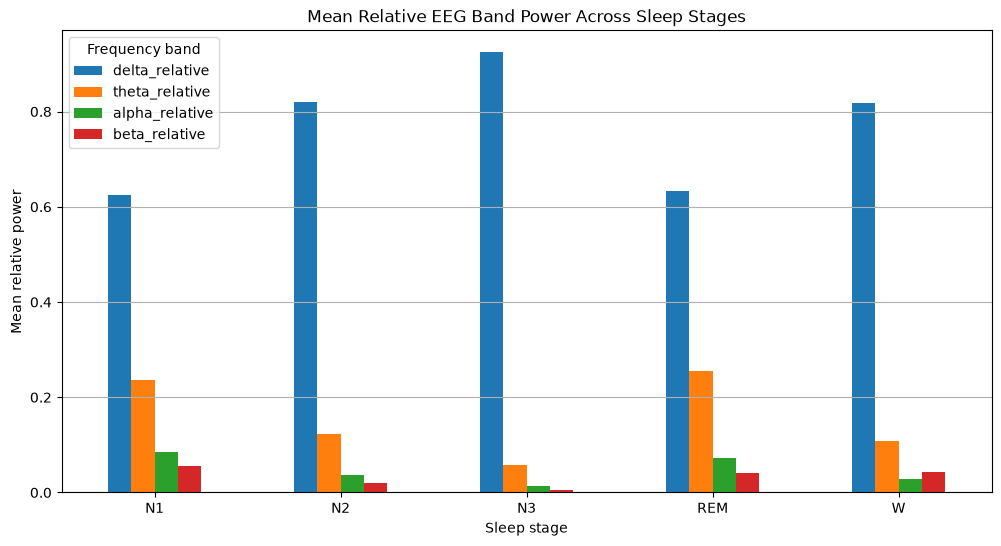

In [43]:
relative_columns = [
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
]

stage_relative_means = (
    model_df
    .groupby("target_stage")[relative_columns]
    .mean()
)

stage_relative_means.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Sleep stage")
plt.ylabel("Mean relative power")
plt.title("Mean Relative EEG Band Power Across Sleep Stages")

plt.xticks(rotation=0)
plt.legend(title="Frequency band")
plt.grid(axis="y")

plt.show()

## 40. Add spectral entropy and dominant frequency

In [44]:
from scipy.stats import entropy

ANALYSIS_LOW = 0.5
ANALYSIS_HIGH = 30.0


def extract_additional_spectral_features(
    epoch,
    sfreq,
    nperseg=1024
):
    """
    Extract spectral entropy and dominant frequency
    from one EEG epoch.

    The analysis is restricted to 0.5–30 Hz.
    """

    frequencies, psd = welch(
        epoch,
        fs=sfreq,
        nperseg=nperseg
    )

    # Keep only the analysis frequency range
    mask = (
        (frequencies >= ANALYSIS_LOW)
        & (frequencies <= ANALYSIS_HIGH)
    )

    analysis_frequencies = frequencies[mask]
    analysis_psd = psd[mask]

    # Normalize PSD into a probability distribution
    psd_sum = np.sum(analysis_psd)

    if psd_sum > 0:
        psd_probability = analysis_psd / psd_sum
    else:
        psd_probability = np.zeros_like(analysis_psd)

    # Spectral entropy
    spectral_entropy = entropy(
        psd_probability,
        base=2
    )

    # Normalize entropy to [0, 1]
    if len(psd_probability) > 1:
        spectral_entropy /= np.log2(len(psd_probability))

    # Dominant frequency
    dominant_frequency = analysis_frequencies[
        np.argmax(analysis_psd)
    ]

    return {
        "spectral_entropy": spectral_entropy,
        "dominant_frequency": dominant_frequency,
    }

## 41. Test additional spectral features

In [45]:
example_index = 1021

additional_features = extract_additional_spectral_features(
    epoch=X_filtered[example_index],
    sfreq=SFREQ
)

print(
    f"SC4001 Epoch {example_index} "
    f"({epochs_df.iloc[example_index]['target_stage']})"
)

for feature_name, value in additional_features.items():
    print(f"{feature_name:>20}: {value:.6f}")

SC4001 Epoch 1021 (N1)
    spectral_entropy: 0.806240
  dominant_frequency: 1.171875


## 42. Extract additional spectral features for all epochs

In [46]:
additional_feature_records = []

for epoch_index, epoch in enumerate(X_filtered):

    features = extract_additional_spectral_features(
        epoch=epoch,
        sfreq=SFREQ
    )

    features["epoch_index"] = epoch_index

    additional_feature_records.append(features)

additional_features_df = pd.DataFrame(
    additional_feature_records
)

additional_features_df = additional_features_df[
    [
        "epoch_index",
        "spectral_entropy",
        "dominant_frequency",
    ]
]

print(
    "Additional feature DataFrame shape:",
    additional_features_df.shape
)

print("\nFirst 5 rows:")
print(additional_features_df.head())

Additional feature DataFrame shape: (2650, 3)

First 5 rows:
   epoch_index  spectral_entropy  dominant_frequency
0            0          0.667405            0.585938
1            1          0.755591            1.074219
2            2          0.604871            1.171875
3            3          0.656860            1.660156
4            4          0.715088            2.050781


## 43. Create final SC4001 spectral feature table

In [47]:
features_df = features_df.merge(
    additional_features_df,
    on="epoch_index",
    how="inner"
)

final_feature_columns = [
    "epoch_index",

    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",

    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",

    "spectral_entropy",
    "dominant_frequency",
]

features_df = features_df[
    final_feature_columns
]

print("Final feature DataFrame shape:")
print(features_df.shape)

print("\nFinal feature columns:")
for column in features_df.columns:
    print(column)

print("\nFirst 5 rows:")
print(features_df.head())

Final feature DataFrame shape:
(2650, 11)

Final feature columns:
epoch_index
delta_absolute
theta_absolute
alpha_absolute
beta_absolute
delta_relative
theta_relative
alpha_relative
beta_relative
spectral_entropy
dominant_frequency

First 5 rows:
   epoch_index  delta_absolute  theta_absolute  alpha_absolute  beta_absolute  \
0            0    4.440571e-10    9.889418e-11    8.991909e-12   1.013694e-11   
1            1    2.597151e-10    4.180098e-11    1.341957e-11   2.940132e-11   
2            2    3.779352e-10    2.401454e-11    1.257038e-11   1.754188e-11   
3            3    2.028651e-10    1.827274e-11    1.337502e-11   7.659840e-12   
4            4    1.260171e-10    4.473053e-11    9.939413e-12   6.435664e-12   

   delta_relative  theta_relative  alpha_relative  beta_relative  \
0        0.790025        0.175943        0.015998       0.018035   
1        0.754247        0.121396        0.038972       0.085385   
2        0.874724        0.055581        0.029094       0.0406

## 44. Discover Sleep-Cassette PSG/Hypnogram pairs

In [48]:
from collections import defaultdict

SC_DIR = DATA_DIR / "sleep-cassette"

psg_files = sorted(SC_DIR.glob("*-PSG.edf"))
hypnogram_files = sorted(SC_DIR.glob("*-Hypnogram.edf"))

print("Number of PSG files:", len(psg_files))
print("Number of hypnogram files:", len(hypnogram_files))

print("\nFirst 10 PSG files:")
for path in psg_files[:10]:
    print(path.name)

print("\nFirst 10 hypnogram files:")
for path in hypnogram_files[:10]:
    print(path.name)

Number of PSG files: 153
Number of hypnogram files: 153

First 10 PSG files:
SC4001E0-PSG.edf
SC4002E0-PSG.edf
SC4011E0-PSG.edf
SC4012E0-PSG.edf
SC4021E0-PSG.edf
SC4022E0-PSG.edf
SC4031E0-PSG.edf
SC4032E0-PSG.edf
SC4041E0-PSG.edf
SC4042E0-PSG.edf

First 10 hypnogram files:
SC4001EC-Hypnogram.edf
SC4002EC-Hypnogram.edf
SC4011EH-Hypnogram.edf
SC4012EC-Hypnogram.edf
SC4021EH-Hypnogram.edf
SC4022EJ-Hypnogram.edf
SC4031EC-Hypnogram.edf
SC4032EP-Hypnogram.edf
SC4041EC-Hypnogram.edf
SC4042EC-Hypnogram.edf


## 45. Create PSG/Hypnogram pairing table

In [49]:
def get_recording_id(filename):
    """
    Extract the common recording identifier.

    Example:
        SC4001E0-PSG.edf
        -> SC4001

        SC4001EC-Hypnogram.edf
        -> SC4001
    """
    return filename[:6]


pairings = defaultdict(dict)

for path in psg_files:
    recording_id = get_recording_id(path.name)
    pairings[recording_id]["psg"] = path

for path in hypnogram_files:
    recording_id = get_recording_id(path.name)
    pairings[recording_id]["hypnogram"] = path


pairing_records = []

for recording_id, files in sorted(pairings.items()):

    pairing_records.append({
        "recording_id": recording_id,
        "psg": files.get("psg"),
        "hypnogram": files.get("hypnogram"),
    })

pairings_df = pd.DataFrame(pairing_records)

print(pairings_df.head(10))

print("\nTotal recording IDs:", len(pairings_df))

print("\nMissing PSG files:")
print(pairings_df[pairings_df["psg"].isna()])

print("\nMissing hypnogram files:")
print(pairings_df[pairings_df["hypnogram"].isna()])

  recording_id                                          psg  \
0       SC4001  ..\data\raw\sleep-cassette\SC4001E0-PSG.edf   
1       SC4002  ..\data\raw\sleep-cassette\SC4002E0-PSG.edf   
2       SC4011  ..\data\raw\sleep-cassette\SC4011E0-PSG.edf   
3       SC4012  ..\data\raw\sleep-cassette\SC4012E0-PSG.edf   
4       SC4021  ..\data\raw\sleep-cassette\SC4021E0-PSG.edf   
5       SC4022  ..\data\raw\sleep-cassette\SC4022E0-PSG.edf   
6       SC4031  ..\data\raw\sleep-cassette\SC4031E0-PSG.edf   
7       SC4032  ..\data\raw\sleep-cassette\SC4032E0-PSG.edf   
8       SC4041  ..\data\raw\sleep-cassette\SC4041E0-PSG.edf   
9       SC4042  ..\data\raw\sleep-cassette\SC4042E0-PSG.edf   

                                           hypnogram  
0  ..\data\raw\sleep-cassette\SC4001EC-Hypnogram.edf  
1  ..\data\raw\sleep-cassette\SC4002EC-Hypnogram.edf  
2  ..\data\raw\sleep-cassette\SC4011EH-Hypnogram.edf  
3  ..\data\raw\sleep-cassette\SC4012EC-Hypnogram.edf  
4  ..\data\raw\sleep-cassette\S